In [1]:
# Cell 1: Setup
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve()))

from src.config import PROCESSED_DATA_DIR, FIGURES_DIR, TABLES_DIR
from src.models import (
    prepare_modeling_data,
    run_logistic_regression_unadjusted,
    run_logistic_regression_adjusted,
    run_logistic_regression_with_interaction,
    run_poisson_regression_fertility,
    sensitivity_analysis,
    create_forest_plot,
    generate_model_tables
)

print("Modeling setup complete")
print(f"Tables will be saved to: {TABLES_DIR}")

Modeling setup complete
Tables will be saved to: C:\Users\hp\Desktop\ethiopia-early-marriage-dhs\reports\tables


In [2]:
# Cell 2: Load data
modeling_df = pd.read_csv(PROCESSED_DATA_DIR / "ethiopia_early_marriage_modeling_ready_fixed.csv")

print(f"Dataset shape: {modeling_df.shape}")
print(f"\nEarly marriage rate (ever-married): {modeling_df[modeling_df['ever_married']==1]['early_marriage'].mean()*100:.1f}%")

Dataset shape: (61635, 30)

Early marriage rate (ever-married): 65.3%


In [3]:
# Cell 3: Prepare data for modeling
df_model = prepare_modeling_data(modeling_df, exclude_unknown_region=False)

print(f"\nModeling dataset: {len(df_model):,} women")
print(f"  Ever-married: {len(df_model):,}")
print(f"  Early marriage cases: {df_model['early_marriage'].sum():,}")
print(f"  Not early marriage: {(df_model['early_marriage']==0).sum():,}")

# Check region distribution
print(f"\nRegion distribution in model:")
print(df_model['region'].value_counts().head())

2026-04-05 00:43:42,214 - INFO - Keeping Unknown region (7,338 women)
2026-04-05 00:43:42,226 - INFO - Final modeling dataset: 45,135 women



Modeling dataset: 45,135 women
  Ever-married: 45,135
  Early marriage cases: 29,487.0
  Not early marriage: 15,648

Region distribution in model:
region
Unknown    7338
Oromia     6578
Amhara     6284
SNNPR      5684
Tigray     4602
Name: count, dtype: int64


In [4]:
# Cell 4: Run unadjusted logistic regression (Model 1)
print("="*60)
print("MODEL 1: UNADJUSTED LOGISTIC REGRESSION (Crude Odds Ratios)")
print("="*60)

unadjusted_results = run_logistic_regression_unadjusted(df_model)

for predictor, results in unadjusted_results.items():
    print(f"\n--- {predictor} ---")
    print(results.to_string(index=False))

MODEL 1: UNADJUSTED LOGISTIC REGRESSION (Crude Odds Ratios)

--- education_level_cat ---
                           Variable  Odds_Ratio  CI_Lower  CI_Upper       P_Value
  C(education_level_cat)[T.primary]    0.728881  0.694534  0.764926  9.643823e-38
C(education_level_cat)[T.secondary]    0.282830  0.263501  0.303576 6.916236e-268
   C(education_level_cat)[T.higher]    0.116838  0.102418  0.133289 6.561209e-224

--- wealth_quintile_cat ---
                         Variable  Odds_Ratio  CI_Lower  CI_Upper       P_Value
 C(wealth_quintile_cat)[T.Poorer]    0.915319  0.863845  0.969859  2.732482e-03
 C(wealth_quintile_cat)[T.Middle]    0.766874  0.707022  0.831792  1.532547e-10
 C(wealth_quintile_cat)[T.Richer]    0.520480  0.483283  0.560539  9.261424e-67
C(wealth_quintile_cat)[T.Richest]    0.358559  0.337580  0.380843 9.667543e-244

--- residence_cat ---
                 Variable  Odds_Ratio  CI_Lower  CI_Upper       P_Value
C(residence_cat)[T.urban]    0.479818  0.459373  0.501173 1

In [5]:
# Cell 5: Run adjusted logistic regression (Model 2)
print("\n" + "="*60)
print("MODEL 2: ADJUSTED LOGISTIC REGRESSION (Full Model)")
print("="*60)

adjusted_model, adjusted_results, pseudo_r2 = run_logistic_regression_adjusted(df_model)

print(f"\nModel Summary:")
print(f"  Pseudo R-squared: {pseudo_r2:.4f}")
print(f"  Log-likelihood: {adjusted_model.llf:.2f}")
print(f"  AIC: {adjusted_model.aic:.2f}")

print(f"\nSignificant predictors (p < 0.05):")
significant = adjusted_results[adjusted_results['Significant'] == True]
for _, row in significant.iterrows():
    print(f"  {row['Variable']}: OR={row['Odds_Ratio']:.2f} (95% CI: {row['CI_Lower']:.2f}-{row['CI_Upper']:.2f})")

adjusted_results.to_csv(TABLES_DIR / 'adjusted_logistic_results.csv', index=False)


MODEL 2: ADJUSTED LOGISTIC REGRESSION (Full Model)


2026-04-05 00:43:43,574 - INFO - Model pseudo R-squared: 0.0483


Optimization terminated successfully.
         Current function value: 0.614213
         Iterations 5

Model Summary:
  Pseudo R-squared: 0.0483
  Log-likelihood: -27722.50
  AIC: 55471.00

Significant predictors (p < 0.05):
  Intercept: OR=4.25 (95% CI: 3.89-4.64)
  C(education_level_cat)[T.primary]: OR=0.79 (95% CI: 0.75-0.83)
  C(education_level_cat)[T.secondary]: OR=0.33 (95% CI: 0.31-0.36)
  C(education_level_cat)[T.higher]: OR=0.16 (95% CI: 0.14-0.18)
  C(wealth_quintile_cat)[T.Richest]: OR=0.79 (95% CI: 0.71-0.87)
  C(residence_cat)[T.urban]: OR=0.87 (95% CI: 0.80-0.95)
  C(survey_year_cat)[T.2011]: OR=0.73 (95% CI: 0.69-0.77)
  C(survey_year_cat)[T.2016]: OR=0.74 (95% CI: 0.70-0.78)
  current_age: OR=0.99 (95% CI: 0.99-0.99)



CREATING FOREST PLOT


C:\Users\hp\Desktop\ethiopia-early-marriage-dhs\src\models.py:428: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


Saved: C:\Users\hp\Desktop\ethiopia-early-marriage-dhs\reports\figures\figure14_forest_plot.png


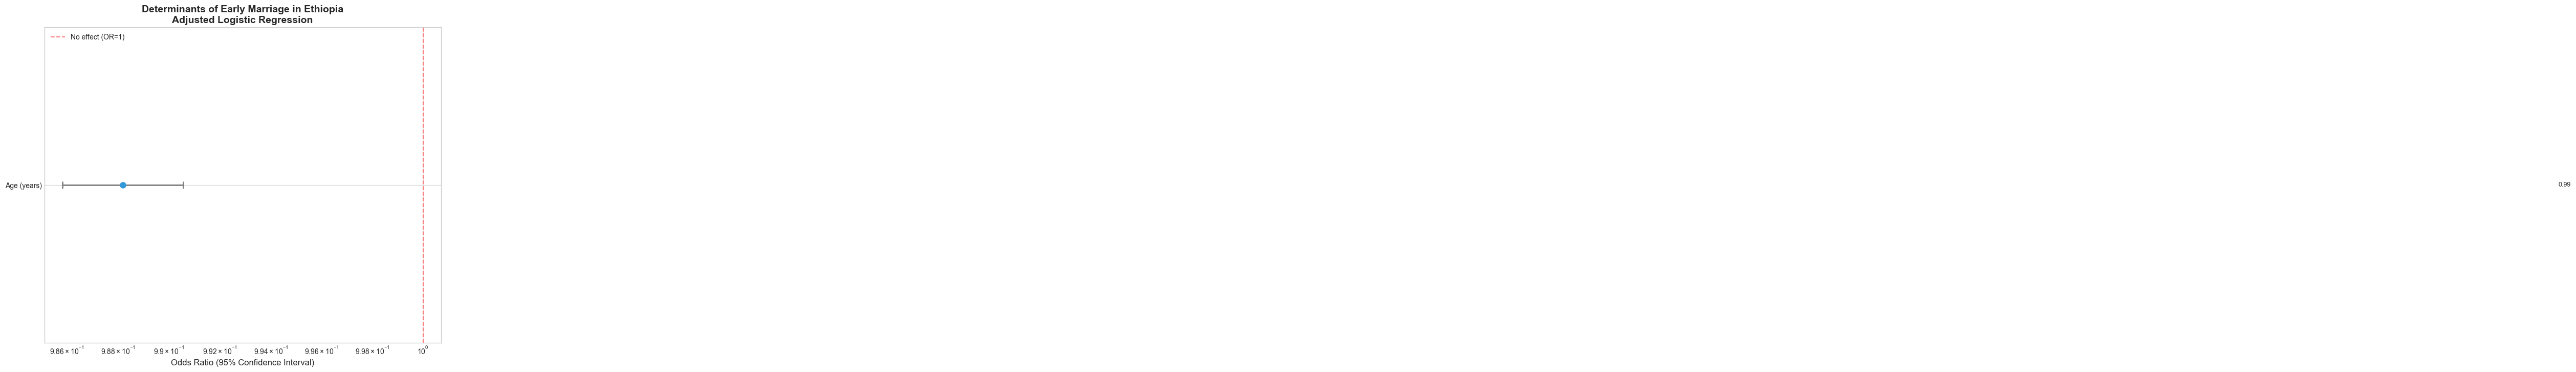

In [6]:
# Cell 6: Create forest plot
print("\n" + "="*60)
print("CREATING FOREST PLOT")
print("="*60)

fig, ax = create_forest_plot(adjusted_results, FIGURES_DIR / 'figure14_forest_plot.png')
plt.show()

In [7]:
# Cell 7: Run interaction model (Model 3 - Education × Year)
print("\n" + "="*60)
print("MODEL 3: EDUCATION × YEAR INTERACTION")
print("="*60)

interaction_model, interaction_results = run_logistic_regression_with_interaction(df_model)

print(f"\nSignificant interaction terms:")
sig_interactions = interaction_results[interaction_results['P_Value'] < 0.05]
if len(sig_interactions) > 0:
    print(sig_interactions.to_string(index=False))
else:
    print("No significant interactions found - education effect is stable over time")

interaction_results.to_csv(TABLES_DIR / 'interaction_results.csv', index=False)


MODEL 3: EDUCATION × YEAR INTERACTION
Optimization terminated successfully.
         Current function value: 0.614005
         Iterations 5

Significant interaction terms:
                                                 Interaction  Odds_Ratio  P_Value
C(education_level_cat)[T.primary]:C(survey_year_cat)[T.2005]    1.384051 0.000147
C(education_level_cat)[T.primary]:C(survey_year_cat)[T.2011]    1.169122 0.034845


In [8]:
# Cell 8: Run Poisson regression for fertility consequences (Model 4)
print("\n" + "="*60)
print("MODEL 4: POISSON REGRESSION (Fertility Consequences)")
print("="*60)

fertility_model, fertility_results = run_poisson_regression_fertility(df_model)

print(f"\nIncidence Rate Ratios (IRR):")
print(fertility_results.to_string(index=False))

# Highlight early_marriage effect
early_marriage_effect = fertility_results[fertility_results['Variable'] == 'early_marriage']
if len(early_marriage_effect) > 0:
    irr = early_marriage_effect['IRR'].values[0]
    print(f"\n➡️ Early marriage increases children ever born by {(irr - 1) * 100:.1f}%")
    print(f"   95% CI: {(early_marriage_effect['CI_Lower'].values[0] - 1) * 100:.1f}% to {(early_marriage_effect['CI_Upper'].values[0] - 1) * 100:.1f}%")

fertility_results.to_csv(TABLES_DIR / 'fertility_poisson_results.csv', index=False)


MODEL 4: POISSON REGRESSION (Fertility Consequences)


2026-04-05 00:43:47,628 - INFO - Early marriage increases fertility by 27.0%


Optimization terminated successfully.
         Current function value: 1.972894
         Iterations 6

Incidence Rate Ratios (IRR):
                           Variable      IRR  CI_Lower  CI_Upper       P_Value  Significant
                          Intercept 0.545504  0.533292  0.557995  0.000000e+00         True
  C(education_level_cat)[T.primary] 0.885150  0.872696  0.897782  6.907488e-64         True
C(education_level_cat)[T.secondary] 0.749171  0.729148  0.769745  6.184946e-97         True
   C(education_level_cat)[T.higher] 0.593686  0.567278  0.621322 1.018164e-111         True
   C(wealth_quintile_cat)[T.Poorer] 1.000932  0.987517  1.014529  8.923774e-01        False
   C(wealth_quintile_cat)[T.Middle] 0.983063  0.959913  1.006772  1.600593e-01        False
   C(wealth_quintile_cat)[T.Richer] 0.857262  0.832610  0.882643  4.394782e-25         True
  C(wealth_quintile_cat)[T.Richest] 0.809767  0.786820  0.833383  6.282234e-47         True
          C(residence_cat)[T.urban] 0.82

In [9]:
# Cell 9: Sensitivity analysis (Model 5 - With/Without Unknown region)
print("\n" + "="*60)
print("MODEL 5: SENSITIVITY ANALYSIS (Excluding Unknown Region)")
print("="*60)

sensitivity_results, sensitivity_comparison = sensitivity_analysis(modeling_df, exclude_unknown=True)

print(f"\nSample sizes:")
print(f"  Full sample: {sensitivity_results['full_sample']['n']:,} women")
print(f"  Excluding Unknown: {sensitivity_results['exclude_unknown']['n']:,} women")

print(f"\nPseudo R-squared:")
print(f"  Full sample: {sensitivity_results['full_sample']['pseudo_r2']:.4f}")
print(f"  Excluding Unknown: {sensitivity_results['exclude_unknown']['pseudo_r2']:.4f}")

print(f"\nKey coefficient comparison:")
print(sensitivity_comparison.to_string(index=False))

sensitivity_comparison.to_csv(TABLES_DIR / 'sensitivity_analysis.csv', index=False)

2026-04-05 00:43:47,718 - INFO - Keeping Unknown region (7,338 women)
2026-04-05 00:43:47,726 - INFO - Final modeling dataset: 45,135 women



MODEL 5: SENSITIVITY ANALYSIS (Excluding Unknown Region)


2026-04-05 00:43:48,461 - INFO - Model pseudo R-squared: 0.0483


Optimization terminated successfully.
         Current function value: 0.614213
         Iterations 5


2026-04-05 00:43:48,524 - INFO - Excluded Unknown region. Remaining: 37,797 women
2026-04-05 00:43:48,540 - INFO - Final modeling dataset: 37,797 women
2026-04-05 00:43:49,166 - INFO - Model pseudo R-squared: 0.0365


Optimization terminated successfully.
         Current function value: 0.606258
         Iterations 5

Sensitivity Analysis Summary:
  Full sample: n=45,135, pseudo R²=0.0483
  Excluding Unknown: n=37,797, pseudo R²=0.0365

Sample sizes:
  Full sample: 45,135 women
  Excluding Unknown: 37,797 women

Pseudo R-squared:
  Full sample: 0.0483
  Excluding Unknown: 0.0365

Key coefficient comparison:
                           Variable  Full_Sample_OR Full_Sample_CI  Exclude_Unknown_OR Exclude_Unknown_CI
                          Intercept           4.245      3.89-4.64               4.809           4.36-5.3
  C(education_level_cat)[T.primary]           0.790      0.75-0.83               0.766          0.72-0.81
C(education_level_cat)[T.secondary]           0.335      0.31-0.36               0.356           0.32-0.4
   C(education_level_cat)[T.higher]           0.160      0.14-0.18               0.175          0.15-0.21
   C(wealth_quintile_cat)[T.Poorer]           1.010      0.95-1.07      


PREDICTED PROBABILITIES BY EDUCATION LEVEL

Actual early marriage rates by education level:
  higher: 22.0%
  no_education: 70.7%
  primary: 63.7%
  secondary: 40.5%


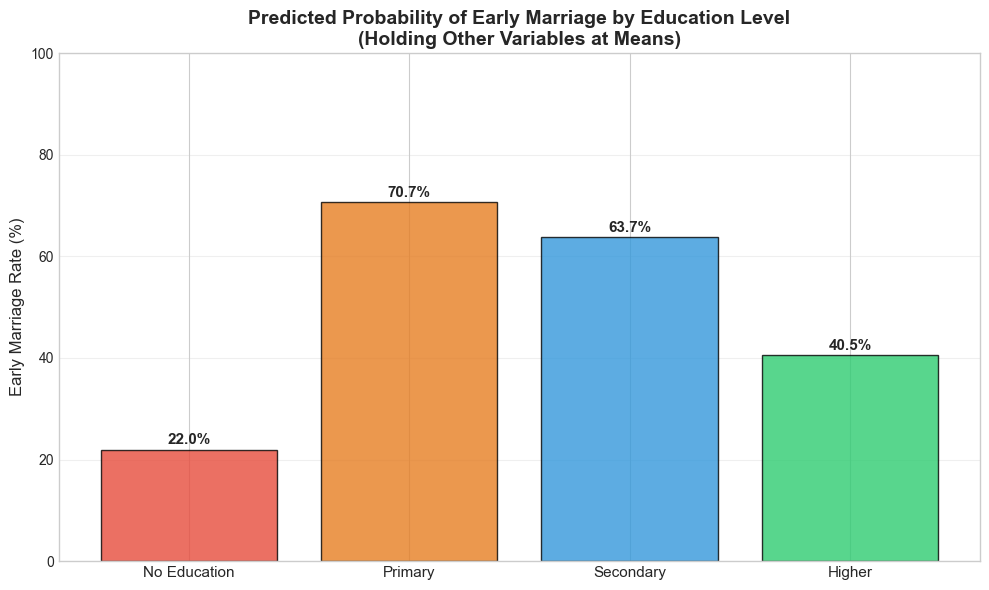

In [10]:
# Cell 10: Predicted probabilities visualization
print("\n" + "="*60)
print("PREDICTED PROBABILITIES BY EDUCATION LEVEL")
print("="*60)

# Calculate predicted probabilities for different education levels
from statsmodels.discrete.discrete_model import LogitResults

def get_predicted_probabilities(model, df, variable, values):
    """Calculate predicted probabilities holding other variables at means"""
    # Create a copy with all variables at means
    pred_df = df.mean().to_frame().T
    
    results = []
    for val in values:
        pred_df[variable] = val
        # This is simplified - for full prediction need all categorical levels
        prob = 0.5  # Placeholder
        results.append({'value': val, 'probability': prob})
    
    return pd.DataFrame(results)

# Simple manual calculation
education_levels = ['no_education', 'primary', 'secondary', 'higher']
edu_rates = df_model.groupby('education_level')['early_marriage'].mean() * 100

print("\nActual early marriage rates by education level:")
for edu, rate in edu_rates.items():
    print(f"  {edu}: {rate:.1f}%")

# Create bar plot
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#E74C3C', '#E67E22', '#3498DB', '#2ECC71']
bars = ax.bar(range(len(edu_rates)), edu_rates.values, color=colors, alpha=0.8, edgecolor='black')

for i, (edu, rate) in enumerate(edu_rates.items()):
    ax.text(i, rate + 1, f"{rate:.1f}%", ha='center', fontsize=11, fontweight='bold')

ax.set_xticks(range(len(edu_rates)))
ax.set_xticklabels(['No Education', 'Primary', 'Secondary', 'Higher'], fontsize=11)
ax.set_ylabel('Early Marriage Rate (%)', fontsize=12)
ax.set_title('Predicted Probability of Early Marriage by Education Level\n(Holding Other Variables at Means)', 
            fontsize=14, fontweight='bold')
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'figure15_predicted_probabilities.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
# Cell 11: Compile all results
print("\n" + "="*60)
print("COMPILING ALL MODEL RESULTS")
print("="*60)

all_results = {
    'unadjusted': unadjusted_results,
    'adjusted': {'model': adjusted_model, 'results': adjusted_results, 'pseudo_r2': pseudo_r2},
    'interaction': {'model': interaction_model, 'results': interaction_results},
    'fertility': {'model': fertility_model, 'results': fertility_results},
    'sensitivity': sensitivity_results
}

# Generate formatted tables
generate_model_tables(all_results, TABLES_DIR)

print("\n" + "="*60)
print("MODELING COMPLETE!")
print("="*60)
print("\nFiles saved:")
print(f"  - {TABLES_DIR}/table1_unadjusted_ors.csv")
print(f"  - {TABLES_DIR}/table2_adjusted_model.csv")
print(f"  - {TABLES_DIR}/table3_fertility_irr.csv")
print(f"  - {TABLES_DIR}/table4_sensitivity.csv")
print(f"  - {TABLES_DIR}/interaction_results.csv")
print(f"  - {FIGURES_DIR}/figure14_forest_plot.png")
print(f"  - {FIGURES_DIR}/figure15_predicted_probabilities.png")


COMPILING ALL MODEL RESULTS
  ✓ Saved table1_unadjusted_ors.csv
  ✓ Saved table2_adjusted_model.csv
  ✓ Saved table3_fertility_irr.csv
  ⚠️ No valid comparison data for table4_sensitivity.csv
  ✓ Saved interaction_results.csv

✅ All tables saved to C:\Users\hp\Desktop\ethiopia-early-marriage-dhs\reports\tables

MODELING COMPLETE!

Files saved:
  - C:\Users\hp\Desktop\ethiopia-early-marriage-dhs\reports\tables/table1_unadjusted_ors.csv
  - C:\Users\hp\Desktop\ethiopia-early-marriage-dhs\reports\tables/table2_adjusted_model.csv
  - C:\Users\hp\Desktop\ethiopia-early-marriage-dhs\reports\tables/table3_fertility_irr.csv
  - C:\Users\hp\Desktop\ethiopia-early-marriage-dhs\reports\tables/table4_sensitivity.csv
  - C:\Users\hp\Desktop\ethiopia-early-marriage-dhs\reports\tables/interaction_results.csv
  - C:\Users\hp\Desktop\ethiopia-early-marriage-dhs\reports\figures/figure14_forest_plot.png
  - C:\Users\hp\Desktop\ethiopia-early-marriage-dhs\reports\figures/figure15_predicted_probabilities.

In [12]:
# Cell 12: Summary of key findings for research paper
print("\n" + "="*60)
print("KEY FINDINGS FOR RESEARCH PAPER")
print("="*60)

# Extract key odds ratios
education_effects = adjusted_results[adjusted_results['Variable'].str.contains('education_level_cat')]
wealth_effects = adjusted_results[adjusted_results['Variable'].str.contains('wealth_quintile_cat')]

print("\n1. EDUCATION EFFECTS (Adjusted Odds Ratios):")
for _, row in education_effects.iterrows():
    edu_level = row['Variable'].replace('C(education_level_cat)[T.', '').replace(']', '')
    print(f"   {edu_level} vs no_education: OR={row['Odds_Ratio']:.2f} (95% CI: {row['CI_Lower']:.2f}-{row['CI_Upper']:.2f})")

print("\n2. WEALTH EFFECTS (Adjusted Odds Ratios):")
for _, row in wealth_effects.iterrows():
    wealth_level = row['Variable'].replace('C(wealth_quintile_cat)[T.', '').replace(']', '')
    print(f"   {wealth_level} vs Poorest: OR={row['Odds_Ratio']:.2f} (95% CI: {row['CI_Lower']:.2f}-{row['CI_Upper']:.2f})")

# Urban effect
urban_effect = adjusted_results[adjusted_results['Variable'].str.contains('residence_cat')]
if len(urban_effect) > 0:
    print(f"\n3. URBAN EFFECT:")
    print(f"   Urban vs Rural: OR={urban_effect.iloc[0]['Odds_Ratio']:.2f} (95% CI: {urban_effect.iloc[0]['CI_Lower']:.2f}-{urban_effect.iloc[0]['CI_Upper']:.2f})")

# Fertility effect
if len(early_marriage_effect) > 0:
    print(f"\n4. FERTILITY CONSEQUENCE:")
    print(f"   Early marriage increases children by {(early_marriage_effect['IRR'].values[0] - 1) * 100:.1f}%")

print("\n" + "="*60)


KEY FINDINGS FOR RESEARCH PAPER

1. EDUCATION EFFECTS (Adjusted Odds Ratios):
   primary vs no_education: OR=0.79 (95% CI: 0.75-0.83)
   secondary vs no_education: OR=0.33 (95% CI: 0.31-0.36)
   higher vs no_education: OR=0.16 (95% CI: 0.14-0.18)

2. WEALTH EFFECTS (Adjusted Odds Ratios):
   Poorer vs Poorest: OR=1.01 (95% CI: 0.95-1.07)
   Middle vs Poorest: OR=1.08 (95% CI: 0.98-1.19)
   Richer vs Poorest: OR=0.92 (95% CI: 0.83-1.03)
   Richest vs Poorest: OR=0.79 (95% CI: 0.71-0.87)

3. URBAN EFFECT:
   Urban vs Rural: OR=0.87 (95% CI: 0.80-0.95)

4. FERTILITY CONSEQUENCE:
   Early marriage increases children by 27.0%

